# Real Data Analysis: Fisher Sharp Null

This notebook reproduces the results of Section 7.3 in the paper "Sequential Monte-Carlo testing by betting".
In particular, it generates plots for Figure S.10.
The same data was used by Rosenbaum (2002) and Ding (2017).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom
import os

np.random.seed(12345)
os.makedirs("results", exist_ok=True)

# Treatment vs. Control trial with binary outcomes. 18 successes among 32 treated
# observations and 5 successes among 21 control observations.

treatment = np.array([1]*32 + [0]*21)
X = np.array([1]*18 + [0]*14 + [1]*5 + [0]*16)

test_stat = np.mean(X[treatment == 1]) - np.mean(X[treatment == 0])

B = 5000 # Maximum number of permutations
B_perm = 200 # Number of permutations for the permutation p-value
m = 1000 # Number of runs
alpha = 0.05 # Significance level
c_param = 0.95 * alpha # Parameter for binomial mixture strategy
p_zero = 1 / np.ceil(np.sqrt(2 * np.pi * np.exp(1 / 6)) / alpha) # Parameter for binomial strategy
h = 8 # Parameter for the Besag-Clifford strategy
B_bc = int(h / alpha) # Maximum number of permutations for the Besag-Clifford strategy

p_perm = np.zeros(m)
p_bin = np.zeros(m)
p_bm = np.zeros(m)
p_bc = np.zeros(m)

idx_dec = np.full(m, B)
dec_bin = np.zeros(m)
idx_dec_bm = np.full(m, B)
idx_dec_bc = np.full(m, B_bc)

dec_bm = np.zeros(m)
dec_perm = np.zeros(m)
dec_bc = np.zeros(m)

myplots_data = [] # To store wealth trajectories for plotting

## Running Simulations

In [2]:
print(f"Running {m} simulations for Fisher sharp null...")

for k in range(m):
    test_stat_perm = np.zeros(B)
    bet_bin = []
    rank = 1
    wealth_bin = [1.0]
    wealth_bm = []
    
    for b in range(B):
        b_1 = b + 1
        X_perm = np.random.permutation(X)
        test_stat_perm[b] = np.mean(X_perm[treatment == 1]) - np.mean(X_perm[treatment == 0])
        
        if test_stat_perm[b] >= test_stat:
            bet_bin.append(p_zero * (b_1 + 1) / rank)
            rank += 1
        else:
            bet_bin.append((1 - p_zero) * (b_1 + 1) / (b_1 - rank + 1))
            
        wealth_bin.append(wealth_bin[-1] * bet_bin[-1])
        if np.max(wealth_bin) >= (1 / alpha) and idx_dec[k] == B:
            idx_dec[k] = b_1
            
        wealth_bm.append((1 - binom.cdf(rank - 1 - 1, b_1 + 1, c_param)) / c_param)
        if np.max(wealth_bm) >= (1 / alpha) and idx_dec_bm[k] == B:
            idx_dec_bm[k] = b_1
            
        if (rank - 1) == h and b_1 < B_bc and idx_dec_bc[k] == B_bc:
            dec_bc[k] = -1
            idx_dec_bc[k] = b_1
        elif b_1 == B_bc and idx_dec_bc[k] == B_bc:
            idx_dec_bc[k] = b_1
            dec_bc[k] = 1

    p_perm[k] = (1 + np.sum(test_stat_perm[:B_perm] >= test_stat)) / (B_perm + 1)
    dec_perm[k] = 1 if p_perm[k] <= alpha else 0
    
    p_bin[k] = 1 / np.max(wealth_bin)
    dec_bin[k] = 1 if p_bin[k] <= alpha else 0
    
    p_bm[k] = 1 / np.max(wealth_bm)
    dec_bm[k] = 1 if p_bm[k] <= alpha else 0
    
    # Store wealth processes for later plotting
    myplots_data.append((np.array(wealth_bin[1:]), np.array(wealth_bm)))

print("Simulations complete.")

Running 1000 simulations for Fisher sharp null...


Simulations complete.


## Statistics

In [3]:
power_p = np.mean(dec_perm)
power_p_bin = np.mean(dec_bin > 0)
mean_idx_dec = np.mean(idx_dec)
median_idx_dec = np.median(idx_dec)

power_p_bm = np.mean(dec_bm > 0)
mean_idx_dec_bm = np.mean(idx_dec_bm)
median_idx_dec_bm = np.median(idx_dec_bm)

power_p_bc = np.mean(dec_bc > 0)
mean_idx_dec_bc = np.mean(idx_dec_bc)
median_idx_dec_bc = np.median(idx_dec_bc)

print("Permutation Power:", power_p)
print("Binomial Power:", power_p_bin, "| Mean Perms:", mean_idx_dec, "| Median Perms:", median_idx_dec)
print("Binomial Mixture Power:", power_p_bm, "| Mean Perms:", mean_idx_dec_bm, "| Median Perms:", median_idx_dec_bm)
print("Besag-Clifford Power:", power_p_bc, "| Mean Perms:", mean_idx_dec_bc, "| Median Perms:", median_idx_dec_bc)

Permutation Power: 0.997
Binomial Power: 1.0 | Mean Perms: 89.198 | Median Perms: 53.0
Binomial Mixture Power: 1.0 | Mean Perms: 4.73 | Median Perms: 1.0
Besag-Clifford Power: 0.985 | Mean Perms: 159.556 | Median Perms: 160.0


## Generate Plots (Figure S.10 Equivalent)
We plot specific runs with different wealth behavior. The paper selected runs m and 5 for the upper plot, and m-2 and m-4 for the lower plot (with 1-based indexing). In python, we use m-1, 4, m-3, m-5.

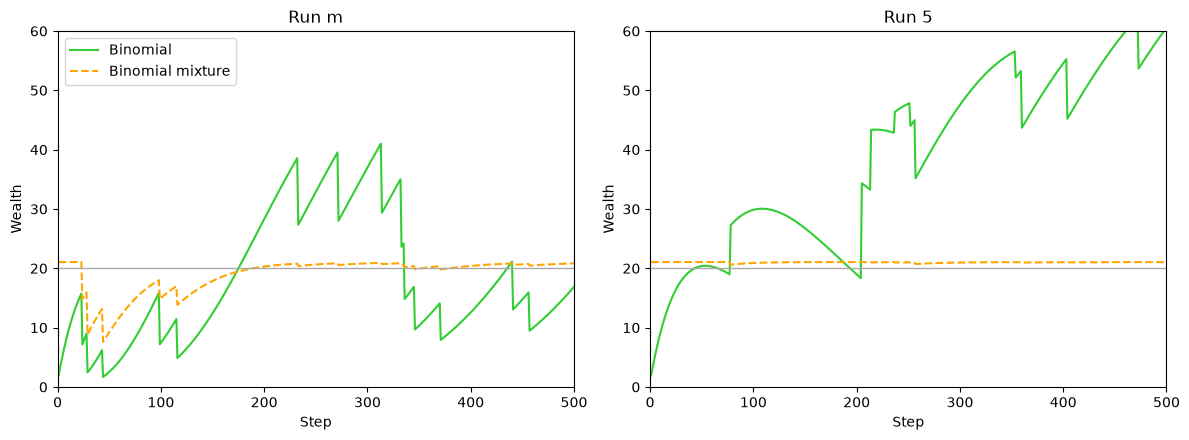

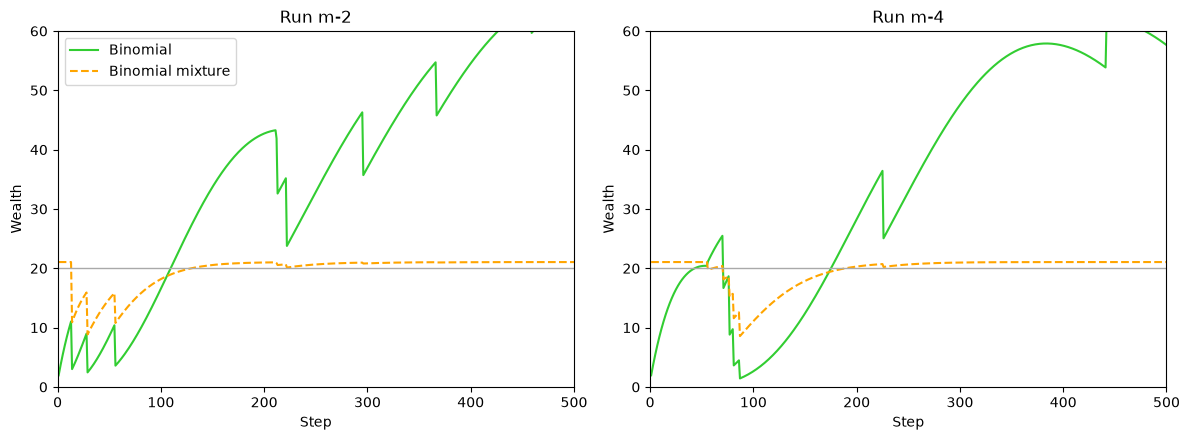

In [4]:
def plot_wealth(ax, k, title):
    wealth_p, wealth_bm_data = myplots_data[k]
    idx = np.arange(1, 5001)
    
    ax.plot(idx, wealth_p, label="Binomial", color="limegreen", linestyle="-")
    ax.plot(idx, wealth_bm_data, label="Binomial mixture", color="orange", linestyle="--")
    ax.axhline(y=1/alpha, color="darkgrey", linewidth=1)
    
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel("Wealth")
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 60)

fig1, axs1 = plt.subplots(1, 2, figsize=(12, 4.5))
plot_wealth(axs1[0], m - 1, "Run m")
plot_wealth(axs1[1], 4, "Run 5")
axs1[0].legend(loc="upper left")
plt.tight_layout()
plt.savefig("results/Plot_wealth_upper.pdf")
plt.show()

fig2, axs2 = plt.subplots(1, 2, figsize=(12, 4.5))
plot_wealth(axs2[0], m - 3, "Run m-2")
plot_wealth(axs2[1], m - 5, "Run m-4")
axs2[0].legend(loc="upper left")
plt.tight_layout()
plt.savefig("results/Plot_wealth_lower.pdf")
plt.show()